<h1 align="center"><font size="7" face="arial" color="#D9027D">Modelling Resting State with TVB</font></h1>

<h3 align="center"><span style="font-weight:normal"><font size="4.5" face="arial">
    Anita Monteverdi, Fulvia Palesi, Marta Gaviraghi, and Roberta Maria Lorenzi  </font></span></h3>

<h1><font size="6" face="arial" color="#BF026D">Context</font></h1>

***

<p><div style="text-align: justify"><font size="4.5" face="time roman">A current topic in system neuroscience literature is the presence of brain activity in the absence of a task condition. These task-negative, spontaneous fluctuations occur in the so-called <b>rest state</b>, and a recurring theme of these fluctuations is that they have a network structure. Because TVB uses the structural connectivity of the brain as the backbone for simulating spontaneous activity, resting state activity and its network structure is a prime candidate for modeling in TVB.</font></div></p>


<h1><font size="6" face="arial" color="#BF026D">Objectives</font></h1>

***

<p><div style="text-align: justify"><font size="4.5" face="time roman">In this notebook, we will start from <b>Zimmerman et al, 2018 </b> to:
<br>
<ul>
    <li>Build a brain network model using subject-specific structural connectivity,</li>
    <li>Globally optimize parameters of the models,</li>
    <li>Define and simulate dynamics of the whole brain at rest,</li>
    <li>Characterize the resting-state activity using the functional connectivity (FC).</li></ul></font></div></p>
    
</br>
<br>
<p><div style="text-align: justify"><font size="4.5" face="time roman"><u>References:</u></font></div></p>
<p><div style="text-align: justify"><font size="4.5" face="time roman"><blockquote>
        <li> Zimmermann, J., Perry, A., Breakspeare, M. et al. <b> Differentiation of Alzheimer's disease based on local and global parameters in personalized Virtual Brain models.</b> NeuroImage:Clinical, 2018, 19, 240-251.</li>

<h1><font size="6" face="arial" color="#BF026D">Exercise</font></h1>

***

<p><div style="text-align: justify"><font size="4.5" face="time roman"></font></div></p>

<h2><font size="5"face="arial" color="black">How to do it with TVB?</font></h2>

<p><div style="text-align: justify"><font size="4.5" face="time roman">In the first part of this tutorial, we presents the basic anatomy of a region simulation using The Virtual Brain scripting interface.
The first thing we want to do is to import the modules we will need for a simulation.</font></div></p>

In [ ]:
%pip install tvb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.8/519.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.9/78.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.4 MB/s eta 0:00:00


In [ ]:
%matplotlib inline

In [ ]:
%%capture
# Import a bunch of stuff to ease command line usage
import os
import numpy as np
import time as tm

import matplotlib
import matplotlib.pyplot as plt

from tvb.simulator.lab import *
from tvb.datatypes.time_series import TimeSeriesRegion
from tvb.datatypes import graph

<h1><font size="5.5" face="arial" color="black">1. Load and prepare connectivity data</font></h1>

<p><div style="text-align: justify"><font size="4.5" face="time roman">Load in and prepare the structural connectivity and functional connectivity from the source we are using.</font></div></p>

<h2><font size="4.5"face="arial" color="black"> Subject-specific structural connectivity</font></h2>

<p><div style="text-align: justify"><font size="4.5" face="time roman">Here, we use a <b>Structural Connectivity (SC) of 126 regions</b> derived from Diffusion Weighted Imaging (DWI) and Constrained Spherical Deconvolution tractography, as previously published in <b>Palesi et al. (2020)</b>. Connections in this SC matrix were defined with an ad-hoc  parcellation scheme combining cerebral cortical and subcortical parcellations (<b>Tzourio-Mazoyer et al., 2002</b>) with cerebellar ones (SUIT, <b>Diedrichsen et al., 2009</b>).
<br>We start by loading and visualizing the SC matrix that represents the set of all existing connections between brain areas.</font></div></p>

<h2><font size="4.5"face="arial" color="black"> Subject-specific functional connectivity</font></h2>

<p><div style="text-align: justify"><font size="4.5" face="time roman">For the same subject, we use a static <b>Functional Connectivity (FC) </b> whose edges were defined as the correlation between the time-courses of pairs of the 126 regions.
<br>We start by loading and visualizing the SC matrix that represents the set of all existing connections between brain areas.</font></div></p>

<p><div style="text-align: justify"><font size="4.5" face="time roman"><u>References:</u></font></div></p>
<p><div style="text-align: justify"><font size="4.5" face="time roman"><blockquote>(Palesi et al., 2020): Palesi, F., Lorenzi, R. M., Casellato, C., Ritter, P., Jirsa, V., Wheeler- kingshott, C. A. M. G., and Angelo, E. D. (2020). <b>The importance of cerebellar connectivity on simulated brain dynamics. </b>Frontiers in Cellular Neuroscience, 14,1–11. <br />
<br>(Monteverdi et al., 2022): Monteverdi A, Palesi F, Costa A, Vitali P, Pichiecchio A, Cotta Ramusino M, Bernini S, Jirsa V,
Gandini Wheeler-Kingshott CAM and D’Angelo E (2022) <b>Subject-specific features of excitation/inhibition profiles in neurodegenerative diseases.</b>
Front. Aging Neurosci. 14:868342. doi: 10.3389/fnagi.2022.868342<br />
<br>(Tzourio-Mazoyer et al., 2002): Tzourio-Mazoyer, N., Landeau, B., Papathanassiou, D., Crivello, F., Etard, O., Delcroix, N., et al. (2002). <b>Automated anatomical labeling ofactivations in SPM using a macroscopic anatomical parcellation of the MNI MRI single-subject brain. </b>Neuroimage 15, 273–289. doi: 10.1006/nimg.2001.0978.<br />
<br>(Diedrichsen et al., 2009): Diedrichsen, J., Balsters, J. H., Flavell, J., Cussans, E., and Ramnani, N. (2009). <b>A probabilistic MR atlas of the human cerebellum.</b> Neuroimage 46, 39–46. doi: 10.1016/j.neuroimage.2009.01.045.<br /></blockquote></font></div></p>

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# Change the path of your Google Drive with the Tutorial folder
root_path = '/content/gdrive/MyDrive/04_TVB/'

In [ ]:
# Define paths for importing empirical structural (SC) and functional connectivity (FC)
pathSC = root_path + 'TVB_data/Conn_plusCRBL.zip'
pathFC = root_path + 'TVB_data/functZ_sparse.txt'

In [ ]:
# Import empirical connectivities

#STRUCTURAL
con = connectivity.Connectivity.from_file(pathSC)
#Define the average axonal speed
con.speed = np.array(10)
print ('')
print ('Maximum SC value = %10.4f' % np.max(con.weights))

#FUNCTIONAL
con_FC = np.genfromtxt(pathFC)


Maximum SC value =     0.0119


<function matplotlib.pyplot.show(close=None, block=None)>

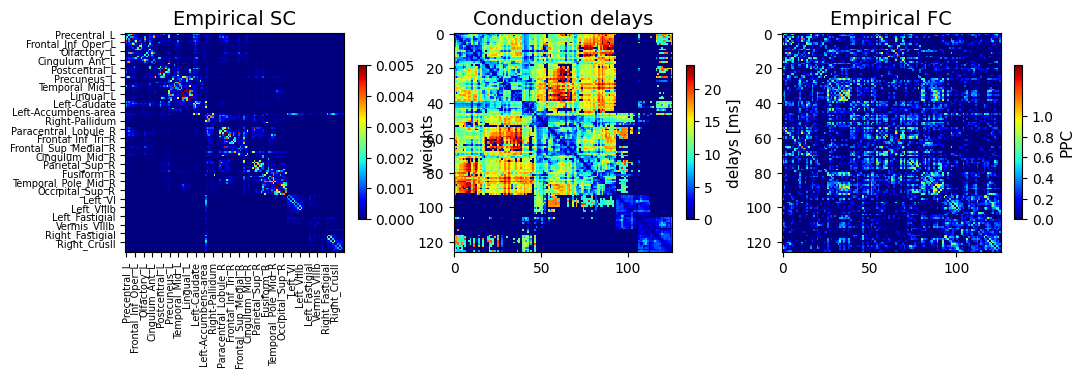

In [ ]:
# Visualize the empirical SC, time delays along SC edges, and FC matrices
fig=plt.figure(figsize=(12,5))
#labels=con.region_labels[0:126:5]
labels=con.region_labels[0:-1:5]

# SC
plt.subplot(131)
#cs=imshow(np.log10(con.weights), cmap='jet', aspect='equal', interpolation='none')
cs=plt.imshow(con.weights, interpolation='none', aspect='equal', cmap='jet', vmax=0.005)
plt.title('Empirical SC', fontsize=14)
plt.xticks(np.arange(0, len(con.region_labels)-1, step=5), labels, fontsize=7, rotation=90)
plt.yticks(np.arange(0, len(con.region_labels)-1, step=5), labels, fontsize=7)
axcb=plt.colorbar(cs, shrink=0.4)
axcb.set_label('weights', fontsize=11)

#delays
plt.subplot(132)
plt.imshow(con.tract_lengths/con.speed, interpolation='none', aspect='equal', cmap='jet')
plt.title('Conduction delays', fontsize=14)
axcb=plt.colorbar(shrink=0.4)
axcb.set_label('delays [ms]', fontsize=11)

# empirical FC
plt.subplot(133)
plt.imshow(con_FC, interpolation='nearest', aspect='equal', cmap='jet')
plt.title('Empirical FC', fontsize=14)
cb=plt.colorbar(shrink=0.4, ticks=[-0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
cb.set_label('PPC', fontsize=11)

plt.show

<h3><font size="5" face="arial" color="black"> 2 Model</font></h3>


<p><div style="text-align: justify"><font size="4.5" face="time roman">In this tutorial, we will use a computational model of resting-state network dynamics: the <b>Reduced Wong-Wang</b>, previously introduced in <b>(Hansen et al., 2015)</b>. This model is a reduction of the model presented in <b>(Wong &#38; Wang, 2006)</b> to a single population model and used in a modeling study of resting-state <b>(Deco et al., 2013; Hansen et al., 2015)</b>. The neural activity of each node is given by the following equations:</font></div></p>

\begin{eqnarray}
    \dfrac{\text{d}S_{i}}{\text{d}t} &=& \dfrac{-S_{i}}{\tau_{s}} + \gamma \ (1 - S_{i})\ H(x_{i}) + \sigma\eta_{i}(t)\\
    &\\
    H(x_{i}) &=& \dfrac{ax_{i} - b}{1 - \exp(-d \ (ax_{i} - b))}\\
    &\\
    x_{i} &=& wJ_{N}S_{i} + J_{N}G\sum_{j}C_{ij}S_{j} + I_{0}
\end{eqnarray}

<p><div style="text-align: justify"><font size="4.5" face="time roman">where $S_{i}$ denotes the average synaptic gating variable at the local area $i$, $H(x_{i})$ is a sigmoid function that converts the input synaptic activity $x_{i}$ into an output population firing rate.</font></div></p>
<p><div style="text-align: justify"><font size="4.5" face="time roman">$C_{ij}$ are the entries of the anatomical structural connectivity matrix reweigthed by the global coupling parameter $G$, with which we will study the optimal dynamical working region where the simulations maximally fit the empirical FC. $\eta_{i}(t)$ is a Gaussian white noise with a noise amplitude $\sigma = 0.001.$</font></div></p>
    

<p><div style="text-align: justify"><font size="4.5" face="time roman">This <b>biologically realistic</b> neural mass model is able to reproduce <b>time-averaged resting state FC</b> as well as the recently introduced <b>FC dynamics</b> with fMRI BOLD signals.</font></div></p>

<p><div style="text-align: justify"><font size="4.5" face="time roman"><u>References:</u></font></div></p>
<p><div style="text-align: justify"><font size="4.5" face="time roman"><blockquote>(Wong &#38; Wang, 2006): Wong, K.-F. &#38; Wang, X.-J. <b>A recurrent network  mechanism of time integration in perceptual decision.</b> J. Neurosci., 2006, 26, 1314-1328. <br />
<br>(Deco et al., 2013): Deco, G., Ponce-Alvarez, A., Mantini, D., Romani, G.L., Hagmann, P. &#38; Corbetta, M. <b>Resting-state functional connectivity emerges from structurally and dynamically shaped slow linear fluctuations.</b> J. Neurosci., 32(27), 11239-11252, 2013.<br />
<br>(Hansen et al., 2015): Hansen, E.C., Battaglia, D., Spiegler, A., Deco, G. &#38; Jirsa V.K. <b>Functional connectivity dynamics: modeling the switching behavior of the resting-state.</b> NeuroImage, 105(2015), 525-535.<br />

In [ ]:
# Initialise a Model.
g2d = models.ReducedWongWang()
g2d

<h3><font size="5"face="arial" color="black"> 3 Coupling function</font></h3>
<p><div style="text-align: justify"><font size="4.5" face="time roman">The coupling function is used to join the local model dynamics at distinct spatial locations.</font></div></p>

In [ ]:
# Initialise a Coupling function.
G = np.array(7.5)
con_coupling = coupling.Scaling(a=G)

<h3><font size="5"face="arial" color="black"> 4 Integrator</font></h3>
<p><div style="text-align: justify"><font size="4.5" face="time roman">Now that we have defined our structure and dynamics, we need to select an integration scheme.
    
<br>We use a stochastic integration scheme where the noise is added. The shape of the noise must correspond to the number of state variables in neural mass models, here equal to 1.
We integrate the coupling and the stochastic terms using a <b>HeunStochastic</b> method, otherwise you can use the detrministic version <b>HeunDeterministic</b>. The step size for the simulation is 0.5.
<br>By default in TVB, the stochastic method assumes that the standard deviation of the noise is a constant equal to: $\sqrt{(2\sigma)}$.
    
<br>
    
<b>NOTE</b> that the most important thing here is to use a step size that is small enough for the integration to be numerically stable.</font></div></p>

In [ ]:
# Initialise an Integrator scheme.
dt = 0.5               #integration steps [ms]

#Change dt to assess how much it impact on the final results

# We can use the deteministic integrator:
# heunint = integrators.HeunDeterministic(dt=dt)

D = 0.001         #standard deviation of the noise
heunstoc=integrators.HeunStochastic(dt=dt, noise=noise.Additive(nsig=np.array([(D**2)/2])))

<h3><font size="5"face="arial" color="black"> 5 Monitors</font></h3>
<p><div style="text-align: justify"><font size="4.5" face="time roman">The last component is Monitor: observer models.
    
<br>Here we select two monitors to get the time series of the model state variables. First, one of the simplest:

* the <b>TemporalAverage</b> monitor averages over a time window of length period returning one time point every period (given in ms).

Then, among other Monitors which apply a biophysical measurement process to the simulated neural activity, such as EEG, MEG, etc, we would like to relate the simulated neural activity to recent fMRI studies, thus we chose:
    
* the <b>BOLD</b> monitor to generate BOLD signal for each regions by using a hemodynamic model.</font></div></p>

In [ ]:
# Initialise some Monitors with period in physical time.
mon_tavg = monitors.TemporalAverage(period=1.) #1000 Hz
TR = 720
mon_bold = monitors.Bold(period=TR)

#Bundle them
what_to_watch = (mon_tavg,mon_bold)

<h1 align="center"><font size="6"face="arial" color="black">Go! Simulate</font></h1>

<p><div style="text-align: justify"><font size="4.5" face="time roman">The last step is to bring all these components together into a <b>Simulator</b> object. We then need to run the configure method, which basically just acts to calculate information necessary for the simulation that draws on specific combinations of the components.</font></div></p>

In [ ]:
# Initialise the Simulator.
regime={'w':np.array(1.), 'I_o':np.array(0.3)}
sim = simulator.Simulator(
    model=models.ReducedWongWang(**regime),
    connectivity=con,
    coupling=con_coupling,
    conduction_speed=float(con.speed),
    integrator=heunstoc,
    monitors=what_to_watch)
sim.initial_conditions = 0.001*np.ones((1, 1, con.weights.shape[0], 1))
sim.configure()

<p><div style="text-align: justify"><font size="4.5" face="time roman">Now, we can run the simulation. All we need to do is iterate for some length, which we provide in *ms*, and collect the output.

The data returned by the simulator is in the form of a list of arrays.</font></div></p>

In [ ]:
# Perform the simulation.
tic = tm.time()

tavg_data, tavg_time = [], []
bold_data, bold_time = [], []

for tavg, bold in sim(simulation_length=360000.):

    if not tavg is None:
        tavg_time.append(tavg[0])
        tavg_data.append(tavg[1])

    if not bold is None:
        bold_time.append(bold[0])
        bold_data.append(bold[1])


'simulation required %0.3f seconds.' % (tm.time()-tic)

'simulation required 402.964 seconds.'

<h1 align="center"><font size="6"face="arial" color="black">Visualize our simulation</font></h1>

<p><div style="text-align: justify"><font size="4.5" face="time roman">And finally, we can look at the results of our simulation, first in terms of time series...</font></div></p>

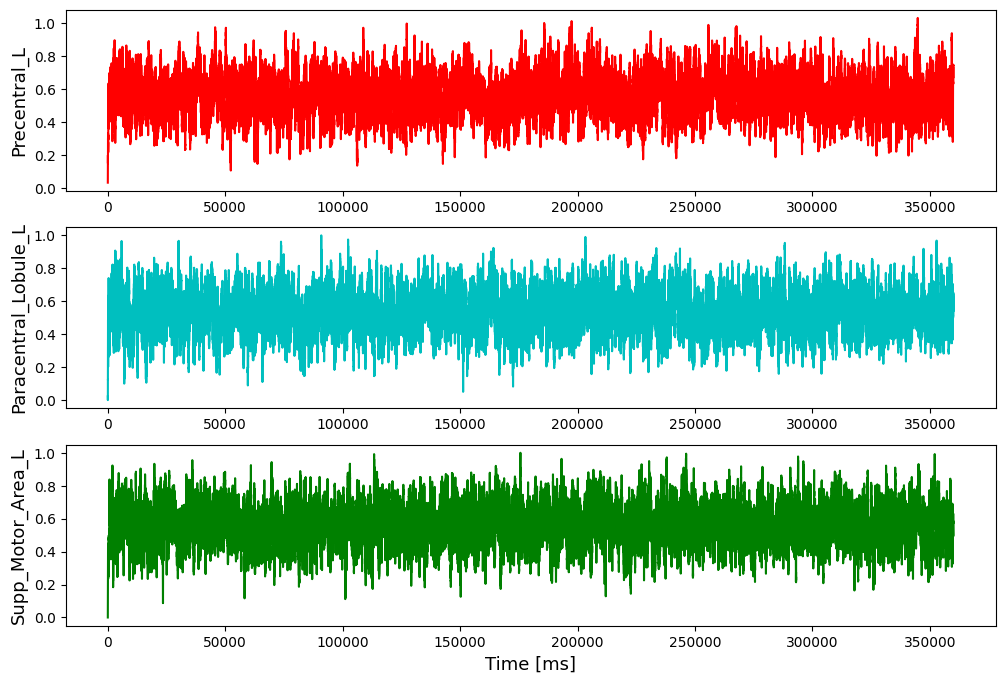

In [ ]:
# Normalize the time series
tavg_data /= (np.max(tavg_data, 0) - np.min(tavg_data, 0))

# Make the lists numpy.arrays for easier use.
TAVG = np.squeeze(np.array(tavg_data))

# Plot the temporally averaged time series
fig2 = plt.figure(figsize=(12,8))
plt.subplot(3,1,1)
plt.plot(tavg_time[:], TAVG[:, 0], 'r')
plt.ylabel(con.region_labels[0],fontsize=13)
plt.subplot(3,1,2)
plt.plot(tavg_time[:], TAVG[:, 1], 'c')
plt.ylabel(con.region_labels[1],fontsize=13)
plt.subplot(3,1,3)
plt.plot(tavg_time[:], TAVG[:, 2], 'g')
plt.xlabel('Time [ms]', fontsize=13)
plt.ylabel(con.region_labels[2],fontsize=13)

plt.show()

<p><div style="text-align: justify"><font size="4.5" face="time roman">...And then reconstructing the simulated FC</font></div></p>

In [ ]:
def eval_fc(tsr):
    input_shape = tsr.data.shape
    result_shape = (input_shape[2], input_shape[2], input_shape[1], input_shape[3])
    result = np.zeros(result_shape)

    for mode in range(result_shape[3]):
        for var in range(result_shape[2]):
            data = tsr.data[:,var,:, mode].squeeze()
            result[:, :, var, mode] = np.corrcoef(data.T)

    corr_coeff = graph.CorrelationCoefficients(source=tsr, array_data=result)
    return corr_coeff

Similarity between empFC and simFC in the whole-brain network:     0.0281


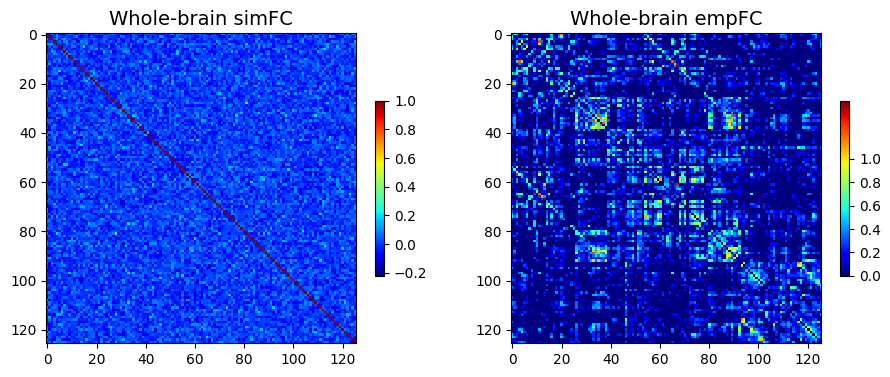

In [ ]:
# Discarded first 10 volumes
data = np.array(bold_data[10:int(360000/720)])
# Build a TimeSeries Dataype
tsr = TimeSeriesRegion(connectivity=con,
                       data=data,
                       sample_period=sim.monitors[1].period)
tsr.configure()
# Compute FC
corrcoeff_data = eval_fc(tsr)
FC = corrcoeff_data.array_data[..., 0, 0]

empFC_wb = np.triu(con_FC, 1) #triangle matrix
simFC_wb = np.triu(FC, 1)
pcc_wb = np.corrcoef(empFC_wb.ravel(), simFC_wb.ravel())[0, 1]
print ('Similarity between empFC and simFC in the whole-brain network: %10.4f' % pcc_wb)

# Visualize and compare the simulated FC and the empirical FC
fig=plt.figure(figsize=(17,7))
# whole-brain network: FC_wb
plt.subplot(131)
p1=plt.imshow(FC, interpolation='nearest', aspect='equal', cmap='jet')
plt.title('Whole-brain simFC', fontsize=14)
cb1=plt.colorbar(p1, shrink=0.325, ticks=[-0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.subplot(132)
p1=plt.imshow(con_FC, interpolation='nearest', aspect='equal', cmap='jet')
plt.title('Whole-brain empFC', fontsize=14)
cb1=plt.colorbar(p1, shrink=0.325, ticks=[-0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

<h1 align="center"><font size="6"face="arial" color="#BF026D">Optimize the model!</font></h1>

<p><div style="text-align: justify"><font size="4.5" face="time roman">The simulation is ended but the model wasn't tune and optimize. Here we add a function for the optimization steps. </font></div></p>

In [ ]:
def run_rww_sim_pcc(con, G, regime, D, dt, TR, simlen):
    # Initialise Simulator.
    sim = simulator.Simulator(
        model=models.ReducedWongWang(**regime),
        connectivity=con,
        coupling=coupling.Scaling(a=np.array(G)),
        conduction_speed=float(con.speed),
        integrator=integrators.HeunStochastic(dt=dt, noise=noise.Additive(nsig=np.array([(D**2)/2]))),
        monitors=(monitors.Bold(period=TR),)
    )
    sim.initial_conditions = (0.001)*np.ones((1, 1, con.weights.shape[0], 1))
    sim.configure()
    # Lunch simulation
    (t, B), = sim.run(simulation_length=simlen)

    # Remove transcient time
    B = B[10:int(simlen/TR), :, :, :]

    # Built a TiemSeries Datatype
    tsr = TimeSeriesRegion(connectivity=con,
                           data=B,
                           sample_period=sim.monitors[0].period)
    tsr.configure()

    # Compute FC
    corrcoeff_data = eval_fc(tsr)
    FC = corrcoeff_data.array_data[..., 0, 0]

    # Take triangular upper part of FC
    FC_triu = np.triu(FC, 1)

    # Compute Pearson correlation
    pcc_FC = np.corrcoef(np.triu(con_FC, 1).ravel(), FC_triu.ravel())[0, 1]
    pcc_SC = np.corrcoef(np.triu(con.weights, 1).ravel(), FC_triu.ravel())[0, 1]

    return pcc_FC, pcc_SC

In [ ]:
#IT TAKES ABOUT 15-20 MINUTES

tic = tm.time()

# Run G sweep
Gs = np.arange(5, 30, 0.5)
regime = {'a': np.array(270.), 'b':np.array(108.), 'd':np.array(0.154),
          'gamma':np.array(0.641/1000), 'w':np.array(1.), 'I_o':np.array(0.3)}

pcc_FC = np.zeros((len(Gs)))
pcc_SC = np.zeros((len(Gs)))
print('simulation start.')
for iG, G in enumerate(Gs):
    print("simulation : G %1.1f" % G)
    pcc_FC[iG], pcc_SC[iG] = run_rww_sim_pcc(con, Gs[iG], regime, 0.001, 1, 720, 60000)


'simulation required %0.3f seconds.' % (tm.time()-tic)

simulation start.
simulation : G 5.0


/var/folders/d6/yt5fqjxj62l66xfddc70c3j40000gn/T/ipykernel_93393/617120175.py:7: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  conduction_speed=np.float(con.speed),


simulation : G 5.5
simulation : G 6.0
simulation : G 6.5
simulation : G 7.0
simulation : G 7.5
simulation : G 8.0
simulation : G 8.5
simulation : G 9.0
simulation : G 9.5
simulation : G 10.0
simulation : G 10.5
simulation : G 11.0
simulation : G 11.5
simulation : G 12.0
simulation : G 12.5
simulation : G 13.0
simulation : G 13.5
simulation : G 14.0
simulation : G 14.5
simulation : G 15.0
simulation : G 15.5
simulation : G 16.0
simulation : G 16.5
simulation : G 17.0
simulation : G 17.5
simulation : G 18.0
simulation : G 18.5
simulation : G 19.0
simulation : G 19.5
simulation : G 20.0
simulation : G 20.5
simulation : G 21.0
simulation : G 21.5
simulation : G 22.0
simulation : G 22.5
simulation : G 23.0
simulation : G 23.5
simulation : G 24.0
simulation : G 24.5
simulation : G 25.0
simulation : G 25.5
simulation : G 26.0
simulation : G 26.5
simulation : G 27.0
simulation : G 27.5
simulation : G 28.0
simulation : G 28.5
simulation : G 29.0
simulation : G 29.5


'simulation required 863.800 seconds.'

<IPython.core.display.Javascript object>


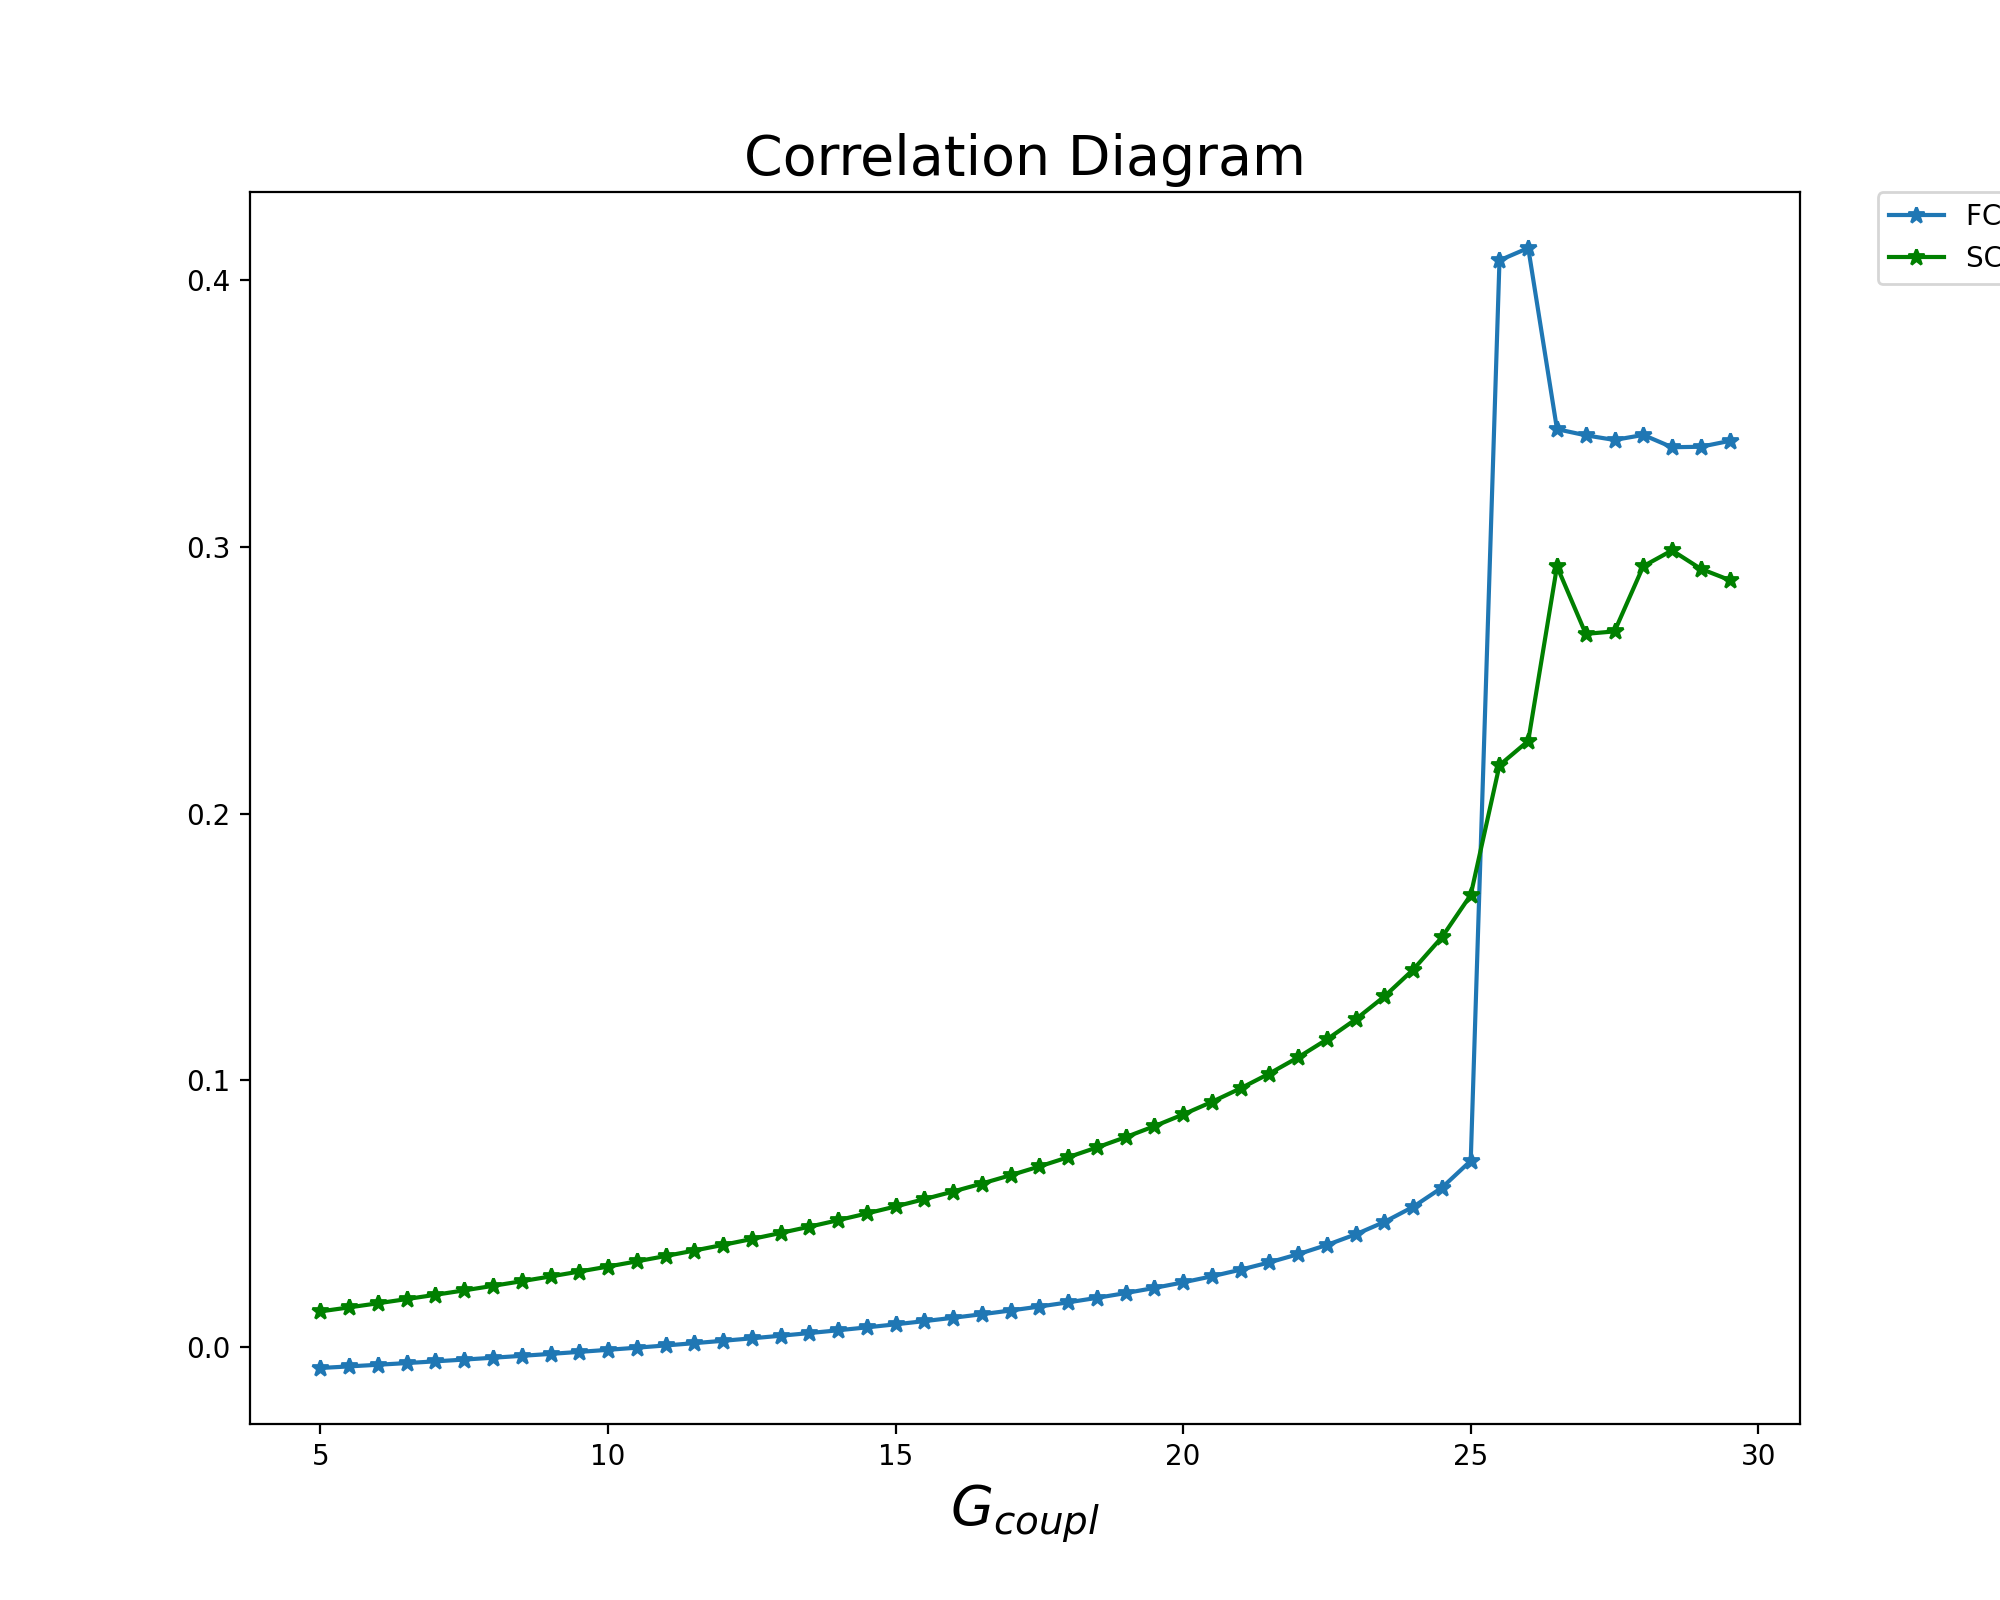

The optimal value for the global coupling is:  26.0


In [ ]:
#DON'T RUN THIS CELL IF YOU DIDN'T RUN THE CELL ABOVE
# Visualize
plt.figure(figsize=(10,8))

# FC and SC
plt.plot(Gs, pcc_FC, '-*', label='FC - FC')
plt.plot(Gs, pcc_SC, '-*g', label='SC - FC')

plt.xlabel('$G_{coupl}$', fontsize=20);
plt.title('Correlation Diagram', fontsize=20)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

plt.show()
Gopt = Gs[np.argmax(pcc_FC)]
print ('The optimal value for the global coupling is: %5.1f' % Gopt)

In [ ]:
# Initialise a Coupling function at the optimal value of G
G = np.array(26)
con_coupling = coupling.Scaling(a=G)

In [ ]:
#IT IS NOT NEEDED SINCE WE HAVE ALREADY INITIALISED IT
# Initialise an Integrator scheme.
dt = 0.5               #integration steps [ms]

D = 0.001         #standard deviation of the noise
heunstoc=integrators.HeunStochastic(dt=dt, noise=noise.Additive(nsig=np.array([(D**2)/2])))

In [ ]:
#IT IS NOT NEEDED SINCE WE HAVE ALREADY INITIALISED IT
# Initialise some Monitors with period in physical time.
mon_tavg = monitors.TemporalAverage(period=1.) #1000 Hz
TR = 720
mon_bold = monitors.Bold(period=TR)

#Bundle them
what_to_watch = (mon_tavg,mon_bold)

In [ ]:
# Initialise the Simulator.
regime={'w':np.array(1.), 'I_o':np.array(0.3)}
sim = simulator.Simulator(
    model=models.ReducedWongWang(**regime),
    connectivity=con,
    coupling=con_coupling,
    conduction_speed=float(con.speed),
    integrator=heunstoc,
    monitors=what_to_watch)
sim.initial_conditions = 0.001*np.ones((1, 1, con.weights.shape[0], 1))
sim.configure()

<ipython-input-24-d578b5017152>:7: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  conduction_speed=np.float(con.speed),


In [ ]:
# Perform the simulation.
tic = tm.time()

tavg_data, tavg_time = [], []
bold_data, bold_time = [], []

for tavg, bold in sim(simulation_length=360000.):

    if not tavg is None:
        tavg_time.append(tavg[0])
        tavg_data.append(tavg[1])

    if not bold is None:
        bold_time.append(bold[0])
        bold_data.append(bold[1])


'simulation required %0.3f seconds.' % (tm.time()-tic)

'simulation required 235.632 seconds.'

<p><div style="text-align: justify"><font size="4.5" face="time roman">Visualize the simulation</font></div></p>

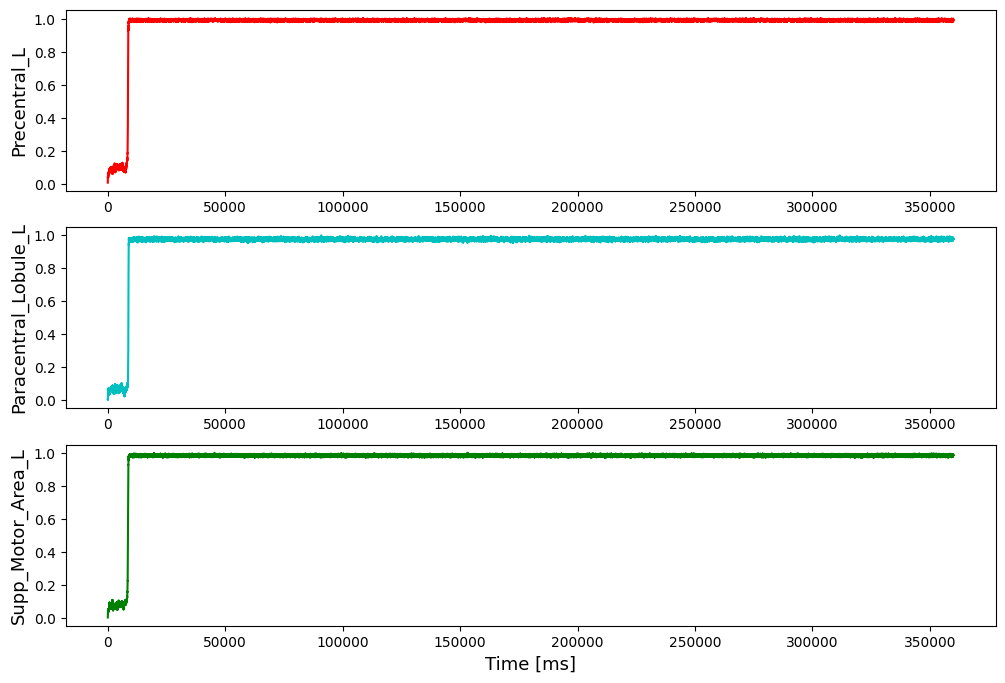

In [ ]:
# Normalize the time series
tavg_data /= (np.max(tavg_data, 0) - np.min(tavg_data, 0))

# Make the lists numpy.arrays for easier use.
TAVG = np.squeeze(np.array(tavg_data))

# Plot the temporally averaged time series
fig2 = plt.figure(figsize=(12,8))
plt.subplot(3,1,1)
plt.plot(tavg_time[:], TAVG[:, 0], 'r')
plt.ylabel(con.region_labels[0],fontsize=13)
plt.subplot(3,1,2)
plt.plot(tavg_time[:], TAVG[:, 1], 'c')
plt.ylabel(con.region_labels[1],fontsize=13)
plt.subplot(3,1,3)
plt.plot(tavg_time[:], TAVG[:, 2], 'g')
plt.xlabel('Time [ms]', fontsize=13)
plt.ylabel(con.region_labels[2],fontsize=13)

plt.show()

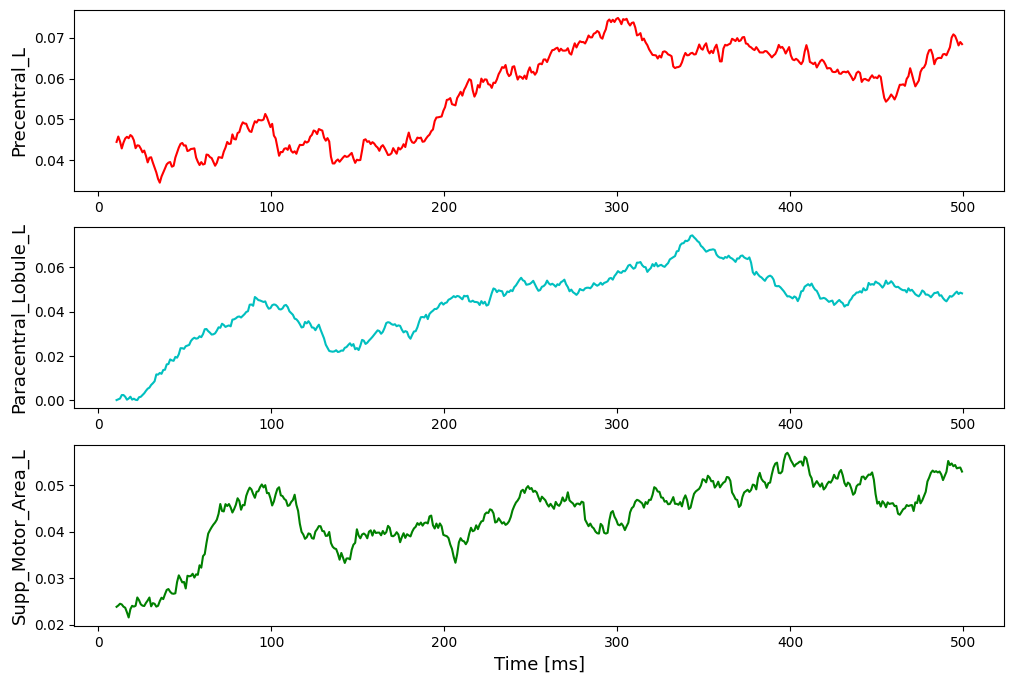

In [ ]:
# Normalize the time series
tavg_data /= (np.max(tavg_data, 0) - np.min(tavg_data, 0))

# Make the lists numpy.arrays for easier use.
TAVG = np.squeeze(np.array(tavg_data))

# Plot the temporally averaged time series
fig2 = plt.figure(figsize=(12,8))
plt.subplot(3,1,1)
plt.plot(tavg_time[10:int(360000/720)], TAVG[10:int(360000/720), 0], 'r')
plt.ylabel(con.region_labels[0],fontsize=13)
plt.subplot(3,1,2)
plt.plot(tavg_time[10:int(360000/720)], TAVG[10:int(360000/720), 1], 'c')
plt.ylabel(con.region_labels[1],fontsize=13)
plt.subplot(3,1,3)
plt.plot(tavg_time[10:int(360000/720)], TAVG[10:int(360000/720), 2], 'g')
plt.xlabel('Time [ms]', fontsize=13)
plt.ylabel(con.region_labels[2],fontsize=13)

plt.show()

<p><div style="text-align: justify"><font size="4.5" face="time roman">...And then reconstructing the simulated FC</font></div></p>

Similarity between empFC and simFC in the whole-brain network:     0.3840


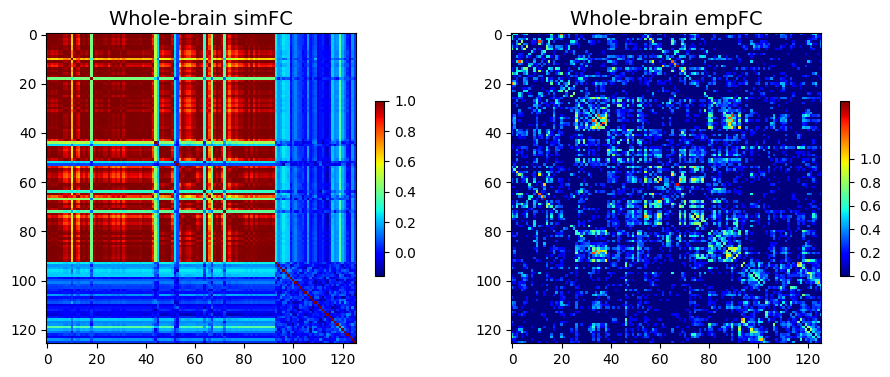

In [ ]:
# Discarded first 10 volumes
data = np.array(bold_data[10:int(360000/720)])
# Build a TimeSeries Dataype
tsr = TimeSeriesRegion(connectivity=con,
                       data=data,
                       sample_period=sim.monitors[1].period)
tsr.configure()
# Compute FC
corrcoeff_data = eval_fc(tsr)
FC = corrcoeff_data.array_data[..., 0, 0]

empFC_wb = np.triu(con_FC, 1) #triangle matrix
simFC_wb = np.triu(FC, 1)
pcc_wb = np.corrcoef(empFC_wb.ravel(), simFC_wb.ravel())[0, 1]
print ('Similarity between empFC and simFC in the whole-brain network: %10.4f' % pcc_wb)

# Visualize and compare the simulated FC and the empirical FC
fig=plt.figure(figsize=(17,7))
# whole-brain network: FC_wb
plt.subplot(131)
p1=plt.imshow(FC, interpolation='nearest', aspect='equal', cmap='jet')
plt.title('Whole-brain simFC', fontsize=14)
cb1=plt.colorbar(p1, shrink=0.325, ticks=[-0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.subplot(132)
p1=plt.imshow(con_FC, interpolation='nearest', aspect='equal', cmap='jet')
plt.title('Whole-brain empFC', fontsize=14)
cb1=plt.colorbar(p1, shrink=0.325, ticks=[-0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

<h1><font size="6" face="arial" color="#BF026D">Now, it's up to you!!</font></h1>

***

<p><div style="text-align: justify"><font size="4.5" face="time roman">These results are starting point for modelling resting state, from which we can base our next simulations.

You can choose one of the following further analyses:
<br>

* Change the integration step of the Heun Stocastic integrator. Try with 1. What does it change?
* <b>Generate optimal whole-brain dynamics in a pathological subject</b>, like an Alzheimer's disease patient. To do this you can use data from files ending with _AD. **(TR = 3010 ms, simlen = 360000 ms)**
* <b>Simulate optimal brain dynamics in a local circuit </b> instead of whole-brain network. To do this you have to define a network that contains only few specific regions that are known to be functinally related one another. For example, the first 93 nodes are belonging to the cerebral connectivity. <i>Tip: for SC you have to set con.weights con.tract_lengths con.centres con.region_labels </i>

</font></div></p>